In [1]:
using Plots, CSV, DataFrames, Printf

In [2]:
g_rels = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
ΩR_rels = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0];

In [56]:
length(g_rels)

21

In [3]:
time_evolutions = [:schroedinger_dynamic]#, :master_dynamic]
corrections = [:correction_off];#, :correction_on]


In [4]:
df_tmp = DataFrame();

In [5]:
df_uni_nocorr = DataFrame();

In [6]:
time_evolutions = [:schroedinger_dynamic]#, :master_dynamic]
corrections = [:correction_off];#, :c
df_tmp = DataFrame();
df_uni_nocorr = DataFrame();
for corr in corrections
    for time_evo in time_evolutions
    
        for g_rel in g_rels 
        
            for ΩR_rel in ΩR_rels
                g_dir = replace("g_$(g_rel)", "." => "_")
                g_dir = replace("g_$(@sprintf("%.2f", g_rel))", "." => "_")
                df = CSV.read("$(time_evo)/$(corr)/$(g_dir)/Chu_g$(g_rel)D_A$(ΩR_rel)D_$(corr)_$(time_evo).csv", DataFrame)
                df_tmp[!, "A$(ΩR_rel)D"] = [df[1, "Infidelities"]]
        
            end
            append!(df_uni_nocorr, df_tmp)
        end
    end
end

In [94]:
fid_best = []
ΩR_best = []

Any[]

In [95]:

for i in 1:length(g_rels)
    val, idx = findmin(Matrix(df_uni_nocorr)[i, :])
    append!(fid_best, val)
    append!(ΩR_best, ΩR_rels[idx])
end


In [97]:
df_uni_nocorr

Row,A0.01D,A0.05D,A0.1D,A0.15D,A0.2D,A0.25D,A0.3D,A0.35D,A0.4D,A0.45D,A0.5D,A0.55D,A0.6D,A0.65D,A0.7D,A0.75D,A0.8D,A0.85D,A0.9D,A0.95D,A1.0D
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,7.80314e-5,0.000105478,0.000341611,0.000815027,0.00131061,0.00207058,0.00251519,0.00449413,0.0051747,0.00509472,0.00923536,0.0118027,0.0133257,0.014687,0.0138155,0.0112193,0.0109202,0.0161576,0.027676,0.0436583,0.0597671
2,0.0314333,0.00195323,0.00128183,0.00247482,0.00197819,0.00292384,0.00395608,0.00539701,0.00705373,0.00668606,0.0110369,0.0142735,0.0161026,0.0173166,0.0160724,0.0130694,0.0124249,0.017426,0.0288478,0.0448785,0.0611561
3,0.430827,0.0220369,0.00781275,0.0091699,0.0049679,0.00615356,0.0088975,0.00849609,0.0131507,0.0118081,0.0166889,0.0219474,0.0247266,0.0254903,0.0230881,0.0188146,0.0170856,0.0213376,0.0324433,0.0486086,0.0654004
4,0.751133,0.0993049,0.0300178,0.0250399,0.0128034,0.0133103,0.0185213,0.0145114,0.0239898,0.0207879,0.0261957,0.0346681,0.0390474,0.0390945,0.0347649,0.0283482,0.0247654,0.0277082,0.0382217,0.0545467,0.0721521
5,0.991062,0.279675,0.0819601,0.0558873,0.0291438,0.026654,0.0345998,0.0244522,0.0404426,0.0343239,0.0397197,0.0522277,0.0587842,0.0578834,0.0508957,0.04148,0.0352655,0.036303,0.0458904,0.0623205,0.0809631
6,0.995762,0.580421,0.17738,0.107525,0.0580539,0.0486155,0.059147,0.039306,0.0632986,0.0531253,0.0575038,0.0745971,0.0839163,0.0818867,0.0715095,0.0581902,0.0484805,0.0469014,0.0550992,0.0714412,0.0912382
7,0.937113,0.946284,0.32478,0.184447,0.103402,0.0812426,0.0940791,0.0598625,0.0930787,0.0779151,0.0798174,0.101597,0.11416,0.110861,0.0964068,0.0782947,0.0642069,0.0592397,0.0654868,0.0814077,0.102333
8,0.913994,0.760122,0.52289,0.289068,0.168453,0.125734,0.141036,0.0867339,0.129736,0.109015,0.10682,0.133212,0.14957,0.144951,0.125741,0.101893,0.0824443,0.073176,0.0767401,0.0917036,0.113549
9,0.993206,0.679955,0.755752,0.420425,0.255263,0.182332,0.201105,0.120616,0.172695,0.146246,0.138363,0.169308,0.19026,0.184464,0.159864,0.129279,0.103368,0.0887144,0.0886551,0.101872,0.124191


Dict{Int64, Array}()

In [124]:
function find_n_best_drive_sets(n_max, df)
    best_drives = Dict{Int, Array}()
    best_infidelities = Dict{Int, Array}()
    # Iterate through "nth best" up to n_max
    for n in 1:n_max
        # Set a new entry to the dict
        best_infidelities[n] = []
        best_drives[n] = []
        
        #Iterate through list of g's
        for i in 1:length(g_rels)
            # For each i, remove the n smallest infidelities to end up with the n'th best
            j = 1
            mat = Matrix(df)[i, :]
            while j < n 
                val, idx = findmin(mat)
                mat[idx] = Inf # To effectively remove it from the list without disrupting the indeces
                j += 1
            end
            # Now find the smallest infidelity after n has been removed
            val, idx = findmin(mat)
            append!(best_infidelities[n], val)
            append!(best_drives[n], ΩR_rels[idx])
            
        end
    end
    return best_drives, best_infidelities
end

find_n_best_drive_sets (generic function with 2 methods)

In [135]:
drives_uni_nocorr, infidelities_uni_nocorr = find_n_best_drive_sets(6, df_uni_nocorr);

In [126]:
drives_uni_nocorr[1]

21-element Vector{Any}:
 0.01
 0.1
 0.2
 0.2
 0.35
 0.35
 0.85
 0.85
 0.9
 0.9
 0.9
 0.9
 0.95
 0.95
 0.95
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

In [117]:
findmin(mat)

(0.0003416111089689089, 3)

In [159]:
drives_nonuni_nocorr, infidelities_nonuni_nocorr = find_n_best_drive_sets(1, df_nonuni_nocorr);

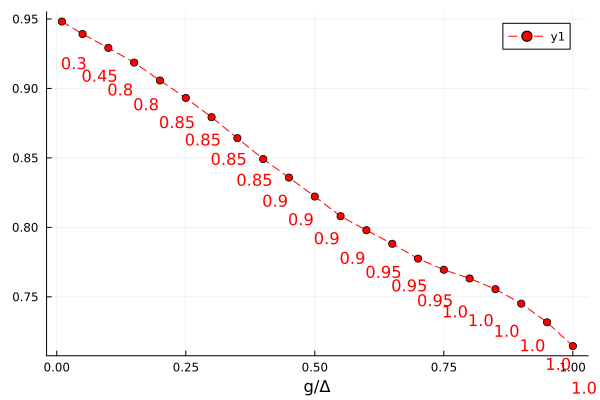

In [160]:
plot(g_rels, 1 .- infidelities_nonuni_nocorr[1], marker = :circle, linestyle = :dash, color = :red, xlabel = "g/Δ")
annotate!.(g_rels, 1 .- infidelities_nonuni_nocorr[1] .- 0.03, text.(drives_nonuni_nocorr[1], :red, :left,11))
plot!()

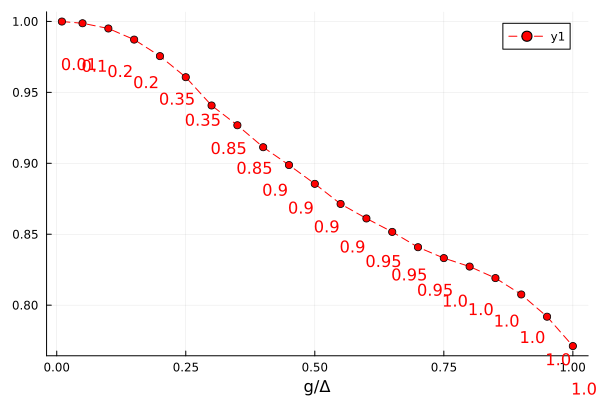

In [153]:
plot(g_rels, 1 .- fid_best, marker = :circle, linestyle = :dash, color = :red, xlabel = "g/Δ")
annotate!.(g_rels, 1 .- fid_best .- 0.03, text.(ΩR_best, :red, :left,11))
#plot!(g_rels, 1 .- infidelities_uni_nocorr[2], marker = :square, lindestyle=:dash, color = :green)
#annotate!.(g_rels, 1 .- infidelities_uni_nocorr[2] .- 0.06, text.(drives_uni_nocorr[2], :green, :left,11))
#plot!(g_rels, 1 .- infidelities_uni_nocorr[3], marker = :star, lindestyle=:dash, color =:blue)
#annotate!(g_rels, 1 .- infidelities_uni_nocorr[3] .- 0.1, text.(drives_uni_nocorr[3], :blue, :left,11))
#plot!(g_rels, 1 .- infidelities_uni_nocorr[4], marker = :circle, lindestyle=:dash, color=:orange)
#annotate!(g_rels, 1 .- infidelities_uni_nocorr[4] .- 0.13, text.(drives_uni_nocorr[4], :orange, :left,11))
#plot!(g_rels, 1 .- infidelities_uni_nocorr[5], marker = :square, lindestyle=:dash, color=:cyan)
#annotate!(g_rels, 1 .- infidelities_uni_nocorr[5] .- 0.16, text.(drives_uni_nocorr[5], :cyan, :left,11))
plot!()

In [76]:
val, idx = findmin(Matrix(df_uni_nocorr)[2,:])

(0.0012818349723688893, 3)

In [78]:
idx

3

In [66]:
forMatrix(df_uni_nocorr)

Row,A0.01D,A0.05D,A0.1D,A0.15D,A0.2D,A0.25D,A0.3D,A0.35D,A0.4D,A0.45D,A0.5D,A0.55D,A0.6D,A0.65D,A0.7D,A0.75D,A0.8D,A0.85D,A0.9D,A0.95D,A1.0D
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,7.80314e-5,0.000105478,0.000341611,0.000815027,0.00131061,0.00207058,0.00251519,0.00449413,0.0051747,0.00509472,0.00923536,0.0118027,0.0133257,0.014687,0.0138155,0.0112193,0.0109202,0.0161576,0.027676,0.0436583,0.0597671
2,0.0314333,0.00195323,0.00128183,0.00247482,0.00197819,0.00292384,0.00395608,0.00539701,0.00705373,0.00668606,0.0110369,0.0142735,0.0161026,0.0173166,0.0160724,0.0130694,0.0124249,0.017426,0.0288478,0.0448785,0.0611561
3,0.430827,0.0220369,0.00781275,0.0091699,0.0049679,0.00615356,0.0088975,0.00849609,0.0131507,0.0118081,0.0166889,0.0219474,0.0247266,0.0254903,0.0230881,0.0188146,0.0170856,0.0213376,0.0324433,0.0486086,0.0654004
4,0.751133,0.0993049,0.0300178,0.0250399,0.0128034,0.0133103,0.0185213,0.0145114,0.0239898,0.0207879,0.0261957,0.0346681,0.0390474,0.0390945,0.0347649,0.0283482,0.0247654,0.0277082,0.0382217,0.0545467,0.0721521
5,0.991062,0.279675,0.0819601,0.0558873,0.0291438,0.026654,0.0345998,0.0244522,0.0404426,0.0343239,0.0397197,0.0522277,0.0587842,0.0578834,0.0508957,0.04148,0.0352655,0.036303,0.0458904,0.0623205,0.0809631
6,0.995762,0.580421,0.17738,0.107525,0.0580539,0.0486155,0.059147,0.039306,0.0632986,0.0531253,0.0575038,0.0745971,0.0839163,0.0818867,0.0715095,0.0581902,0.0484805,0.0469014,0.0550992,0.0714412,0.0912382
7,0.937113,0.946284,0.32478,0.184447,0.103402,0.0812426,0.0940791,0.0598625,0.0930787,0.0779151,0.0798174,0.101597,0.11416,0.110861,0.0964068,0.0782947,0.0642069,0.0592397,0.0654868,0.0814077,0.102333
8,0.913994,0.760122,0.52289,0.289068,0.168453,0.125734,0.141036,0.0867339,0.129736,0.109015,0.10682,0.133212,0.14957,0.144951,0.125741,0.101893,0.0824443,0.073176,0.0767401,0.0917036,0.113549
9,0.993206,0.679955,0.755752,0.420425,0.255263,0.182332,0.201105,0.120616,0.172695,0.146246,0.138363,0.169308,0.19026,0.184464,0.159864,0.129279,0.103368,0.0887144,0.0886551,0.101872,0.124191


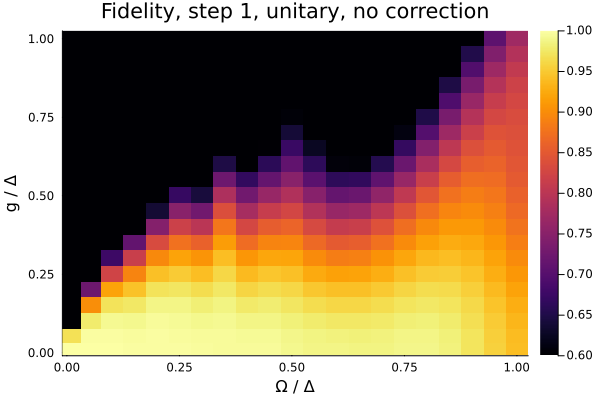

In [144]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_uni_nocorr), clims = (0.6, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, unitary, no correction")
#savefig("Step1_Unitary_NoCorr_fullrange.pdf")

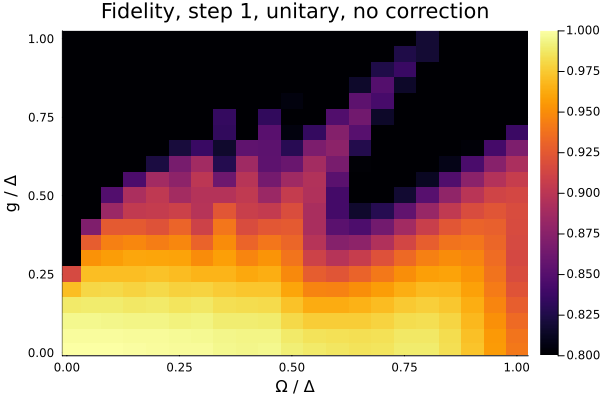

In [63]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_uni_corr), clims = (0.8, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, unitary, with correction")


In [48]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_uni_nocorr), clims = (0.8, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, unitary, no correction")
#savefig("Step1_Unitary_NoCorr_crop.pdf")

"/Users/mariushope/dev/git/NN_QM/HBAR-qubit_problem/data/simple_ladder/Step1_Unitary_NoCorr_crop.pdf"

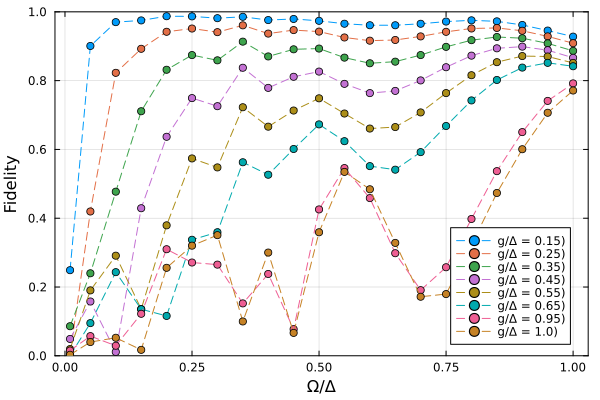

In [171]:
plot(ΩR_rels, 1 .- Matrix(df_uni_nocorr)[4, :], label = "g/Δ = $(g_rels[4]))", ylims = (0.5, 1.0), marker = :circle, linestyle = :dash)
plot!(ΩR_rels, 1 .- Matrix(df_uni_nocorr)[6, :], label = "g/Δ = $(g_rels[6]))", ylims = (0.8, 1.0), marker = :circle, linestyle = :dash)
plot!(ΩR_rels, 1 .- Matrix(df_uni_nocorr)[8, :], label = "g/Δ = $(g_rels[8]))", ylims = (0.8, 1.0), marker = :circle, linestyle = :dash)
plot!(ΩR_rels, 1 .- Matrix(df_uni_nocorr)[10, :], label = "g/Δ = $(g_rels[10]))", ylims = (0.8, 1.0), marker = :circle, linestyle = :dash)
plot!(ΩR_rels, 1 .- Matrix(df_uni_nocorr)[12, :], label = "g/Δ = $(g_rels[12]))", ylims = (0.8, 1.0), marker = :circle, linestyle = :dash)
plot!(ΩR_rels, 1 .- Matrix(df_uni_nocorr)[14, :], label = "g/Δ = $(g_rels[14]))", ylims = (0.8, 1.0), marker = :circle, linestyle = :dash)
plot!(ΩR_rels, 1 .- Matrix(df_uni_nocorr)[20, :], label = "g/Δ = $(g_rels[20]))", ylims = (0.0, 1.0), marker = :circle, linestyle = :dash)
plot!(ΩR_rels, 1 .- Matrix(df_uni_nocorr)[21, :], label = "g/Δ = $(g_rels[21]))", ylims = (0.0, 1.0), marker = :circle, linestyle = :dash)

plot!(xlabel = "Ω/Δ", ylabel = "Fidelity", framestyle = :box)

In [18]:
time_evolutions = [:schroedinger_dynamic]#, :master_dynamic]
corrections = [:correction_on];#, :c
df_tmp = DataFrame();
df_uni_corr = DataFrame();
for corr in corrections
    for time_evo in time_evolutions
    
        for g_rel in g_rels 
        
            for ΩR_rel in ΩR_rels
                g_dir = replace("g_$(g_rel)", "." => "_")
                g_dir = replace("g_$(@sprintf("%.2f", g_rel))", "." => "_")
                df = CSV.read("$(time_evo)/$(corr)/$(g_dir)/Chu_g$(g_rel)D_A$(ΩR_rel)D_$(corr)_$(time_evo).csv", DataFrame)
                df_tmp[!, "A$(ΩR_rel)D"] = [df[1, "Infidelities"]]
        
            end
            append!(df_uni_corr, df_tmp)
        end
    end
end

In [49]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_uni_corr), clims = (0.0, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, unitary, with correction")
savefig("Step1_Unitary_Corr_fullrange.pdf")

"/Users/mariushope/dev/git/NN_QM/HBAR-qubit_problem/data/simple_ladder/Step1_Unitary_Corr_fullrange.pdf"

In [50]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_uni_corr), clims = (0.8, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, unitary, with correction")
savefig("Step1_Unitary_Corr_crop.pdf")

"/Users/mariushope/dev/git/NN_QM/HBAR-qubit_problem/data/simple_ladder/Step1_Unitary_Corr_crop.pdf"

In [156]:
time_evolutions = [:master_dynamic]#, :master_dynamic]
corrections = [:correction_off];#, :c
df_tmp = DataFrame();
df_nonuni_nocorr = DataFrame();
for corr in corrections
    for time_evo in time_evolutions
    
        for g_rel in g_rels 
        
            for ΩR_rel in ΩR_rels
                g_dir = replace("g_$(g_rel)", "." => "_")
                g_dir = replace("g_$(@sprintf("%.2f", g_rel))", "." => "_")
                df = CSV.read("$(time_evo)/$(corr)/$(g_dir)/Chu_g$(g_rel)D_A$(ΩR_rel)D_$(corr)_$(time_evo).csv", DataFrame)
                df_tmp[!, "A$(ΩR_rel)D"] = [df[1, "Infidelities"]]
                
            end
            append!(df_nonuni_nocorr, df_tmp)
        end
    end
end

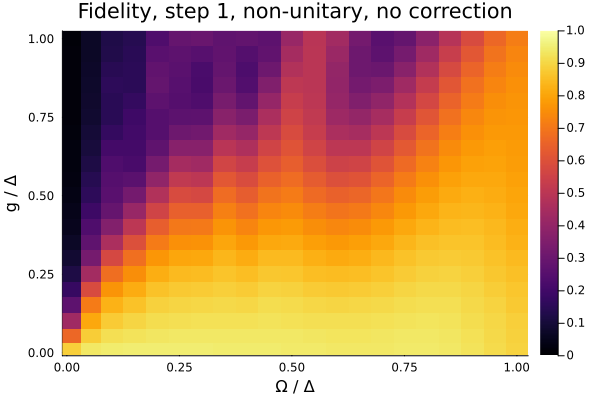

In [157]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_nonuni_nocorr), clims = (0.0, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, non-unitary, no correction")
#savefig("Step1_NonUnitary_NoCorr_fullrange.pdf")

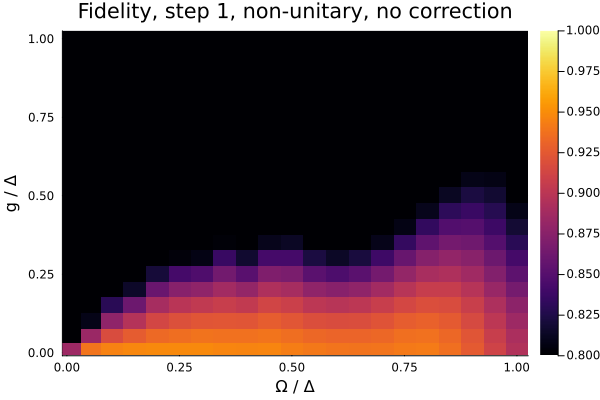

In [158]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_nonuni_nocorr), clims = (0.8, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, non-unitary, no correction")
#savefig("Step1_NonUnitary_NoCorr_crop.pdf")

In [38]:
time_evolutions = [:master_dynamic]#, :master_dynamic]
corrections = [:correction_on];#, :c
df_tmp = DataFrame();
df_nonuni_corr = DataFrame();
for corr in corrections
    for time_evo in time_evolutions
        for g_rel in g_rels 
            for ΩR_rel in ΩR_rels
                g_dir = replace("g_$(g_rel)", "." => "_")
                g_dir = replace("g_$(@sprintf("%.2f", g_rel))", "." => "_")
                df = CSV.read("$(time_evo)/$(corr)/$(g_dir)/Chu_g$(g_rel)D_A$(ΩR_rel)D_$(corr)_$(time_evo).csv", DataFrame)
                df_tmp[!, "A$(ΩR_rel)D"] = [df[1, "Infidelities"]]
                
            end
            append!(df_nonuni_corr, df_tmp)
        end
    end
end

In [53]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_nonuni_corr), clims = (0.0, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, non-unitary, with correction")
savefig("Step1_NonUnitary_Corr_fullrange.pdf")

"/Users/mariushope/dev/git/NN_QM/HBAR-qubit_problem/data/simple_ladder/Step1_NonUnitary_Corr_fullrange.pdf"

In [54]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_nonuni_corr), clims = (0.8, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, non-unitary, with correction")
savefig("Step1_NonUnitary_Corr_crop.pdf")

"/Users/mariushope/dev/git/NN_QM/HBAR-qubit_problem/data/simple_ladder/Step1_NonUnitary_Corr_crop.pdf"

In [ ]:
plot(ΩR_rels, 1 .- step1_g05, linestyle=:dash, marker = :circle, label = "g = 0.05 Δ")
plot!(framestyle = :box, title = "Step 1, non-unitary dynamics, no correction", ylabel = "Fidelity", xlabel = "Ω / Δ", ylims = (0.90, 1.01))
savefig("Step1_Non-Unitary_NoCorr_g_0_05.pdf")

In [ ]:
heatmap(g_rels, g_rels, 1 .- Matrix(df_grid), clims = (0.8, 1.0), xlabel = "Ω / Δ", ylabel = "g / Δ", title = "Fidelity, step 1, unitary, no corr")
#savefig("Step1_Unitary_NoCorr_heatmap.pdf")

In [ ]:
plot(ΩR_rels, 1 .- Matrix(df_grid)[8,:], linestyle=:dash, marker = :circle)
plot!(legend=:topright, framestyle = :box, title = "Step 1, unitary dynamics, no correction", xscale=:log10, xlims = (0.005, 3.5), ylabel = "Fidelity", xlabel = "Ω / Δ", xticks = ([0.01, 0.05, 0.1, 0.5, 1.0, 1.5, 2.0, 3.0], ["0.01", "0.05", "0.1", "0.5", "1.0", "1.5", "2.0", "3.0"]), ylims = (-0.05, 1.1))
#savefig("Step1_Unitary_NoCorr_g_2_5_vs_Amplitude.pdf")

In [ ]:
df_corr

In [ ]:
step1_A0_01 = [df_comb[!, "g0.01D_A0.01D"][1], df_comb[!, "g0.1D_A0.01D"][1], df_comb[!, "g0.5D_A0.01D"][1]]

In [ ]:
step1_A0_05 = [df_comb[!, "g0.01D_A0.05D"][1], df_comb[!, "g0.1D_A0.05D"][1], df_comb[!, "g0.5D_A0.05D"][1]]

In [ ]:
step1_A0_1 = [df_comb[!, "g0.01D_A0.1D"][1], df_comb[!, "g0.1D_A0.1D"][1], df_comb[!, "g0.5D_A0.1D"][1]]

In [ ]:
x = [0.01, 0.1, 0.5]

In [ ]:
plot(x, 1 .- step1_A0_01, linestyle=:dash, marker = :circle, label = "Ω = 0.01 Δ")
plot!(x, 1 .- step1_A0_05, linestyle=:dash, marker = :circle, label = "Ω = 0.05 Δ")
plot!(x, 1 .- step1_A0_1, linestyle=:dash, marker = :circle, label = "Ω = 0.1 Δ")
plot!(framestyle = :box, title = "Step 1, unitary dynamics, no correction", xscale=:log10, xlims = (0.005, 1.0), ylabel = "Fidelity", xlabel = "g / Δ", xticks = ([0.01, 0.1, 0.5], ["0.01", "0.1", "0.5"]), ylims = (-0.05, 1.1))
savefig("Step1_Unitary_NoCorr.pdf")

In [ ]:
plot(x, 1 .- step1_A0_01, linestyle=:dash, marker = :circle, label = "Ω = 0.01 Δ")
plot!(framestyle = :box, title = "Step 1, unitary dynamics, no correction", xscale=:log10, xlims = (0.005, 1.0), ylabel = "Fidelity", xlabel = "g / Δ", xticks = ([0.01, 0.1, 0.5], ["0.01", "0.1", "0.5"]), ylims = (-0.05, 1.1))

In [ ]:
df_corr = DataFrame()

In [ ]:
for ΩR_rel in ΩR_rels
    for g_rel in g_rels 
        df = CSV.read("Unitary/Chu_g$(g_rel)D_A$(ΩR_rel)D_correction_on_schroedinger_dynamic.csv", DataFrame)
        df_corr[!, "g$(g_rel)D_A$(ΩR_rel)D"] = df[!, "Infidelities"]
    end
end


In [ ]:
corr_A0_01 = [df_corr[!, "g0.01D_A0.01D"][1], df_corr[!, "g0.1D_A0.01D"][1], df_corr[!, "g0.5D_A0.01D"][1]]

In [ ]:
corr_A0_05 = [df_corr[!, "g0.01D_A0.05D"][1], df_corr[!, "g0.1D_A0.05D"][1], df_corr[!, "g0.5D_A0.05D"][1]]

In [ ]:
corr_A0_1 = [df_corr[!, "g0.01D_A0.1D"][1], df_corr[!, "g0.1D_A0.1D"][1], df_corr[!, "g0.5D_A0.1D"][1]]

In [ ]:
plot(x, 1 .- corr_A0_01, linestyle=:dash, marker = :circle, label = "Ω = 0.01 Δ")
plot!(x, 1 .- corr_A0_05, linestyle=:dash, marker = :circle, label = "Ω = 0.05 Δ")
plot!(x, 1 .- corr_A0_1, linestyle=:dash, marker = :circle, label = "Ω = 0.1 Δ")
plot!(framestyle = :box, title = "Step 1, unitary dynamics, with correction", xscale=:log10, xlims = (0.005, 1.0), ylabel = "Fidelity", xlabel = "g / Δ", xticks = ([0.01, 0.1, 0.5], ["0.01", "0.1", "0.5"]), ylims = (-0.05, 1.1))
savefig("Step1_Unitary_Corr.pdf")

In [ ]:
df_mast = DataFrame()

In [ ]:
for ΩR_rel in ΩR_rels
    for g_rel in g_rels 
        df = CSV.read("Non-unitary/Chu_g$(g_rel)D_A$(ΩR_rel)D_correction_off_master_dynamic.csv", DataFrame)
        df_mast[!, "g$(g_rel)D_A$(ΩR_rel)D"] = df[!, "Infidelities"]
    end
end

In [ ]:
mast_A0_01 = [df_mast[!, "g0.01D_A0.01D"][1], df_mast[!, "g0.1D_A0.01D"][1], df_mast[!, "g0.5D_A0.01D"][1]]

In [ ]:
mast_A0_05 = [df_mast[!, "g0.01D_A0.05D"][1], df_mast[!, "g0.1D_A0.05D"][1], df_mast[!, "g0.5D_A0.05D"][1]]

In [ ]:
mast_A0_1 = [df_mast[!, "g0.01D_A0.1D"][1], df_mast[!, "g0.1D_A0.1D"][1], df_mast[!, "g0.5D_A0.1D"][1]]

In [ ]:
plot(x, 1 .- mast_A0_01, linestyle=:dash, marker = :circle, label = "Ω = 0.01 Δ")
plot!(x, 1 .- mast_A0_05, linestyle=:dash, marker = :circle, label = "Ω = 0.05 Δ")
plot!(x, 1 .- mast_A0_1, linestyle=:dash, marker = :circle, label = "Ω = 0.1 Δ")
plot!(framestyle = :box, title = "Step 1, non-unitary dynamics, no correction", xscale=:log10, xlims = (0.005, 1.0), ylabel = "Fidelity", xlabel = "g / Δ", xticks = ([0.01, 0.1, 0.5], ["0.01", "0.1", "0.5"]), ylims = (-0.05, 1.1))
savefig("Step1_Non-unitary_NoCorr.pdf")

In [ ]:
g_rels = [0.5]
ΩR_rels = [0.01, 0.05, 0.1, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.5]


In [ ]:
df_A = DataFrame()

In [ ]:
for ΩR_rel in ΩR_rels
    for g_rel in g_rels 
        df = CSV.read("Unitary/Chu_g$(g_rel)D_A$(ΩR_rel)D_correction_off_schroedinger_dynamic.csv", DataFrame)
        df_A[!, "g$(g_rel)D_A$(ΩR_rel)D"] = df[!, "Infidelities"]
    end
end

In [ ]:
df_A

In [ ]:
step1 = Matrix(df_A)[1, :]

In [ ]:
plot(ΩR_rels, 1 .- step1, linestyle=:dash, marker = :circle, label = "g = 0.5 Δ")
plot!(framestyle = :box, title = "Step 1, unitary dynamics, no correction", xscale=:log10, xlims = (0.005, 1.6), ylabel = "Fidelity", xlabel = "Ω / Δ", xticks = ([0.01, 0.05, 0.1, 0.5, 1.0, 1.5], ["0.01", "0.05", "0.1", "0.5", "1.0", "1.5"]), ylims = (-0.05, 1.1))
savefig("Step1_Unitary_NoCorr_vs_Amplitude.pdf")

In [ ]:
df_A[1, :]